In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [32]:
df = pd.read_csv('/content/weight-height.csv')

In [33]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [34]:
df.shape

(10000, 3)

In [35]:
df['Height'].describe()

,Height
count,10000.000000
mean,66.367560
std,3.847528
min,54.263133
25%,63.505620
50%,66.318070
75%,69.174262
max,78.998742


/tmp/ipykernel_18461/4116268081.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'],hist=False)


<Axes: xlabel='Height', ylabel='Density'>

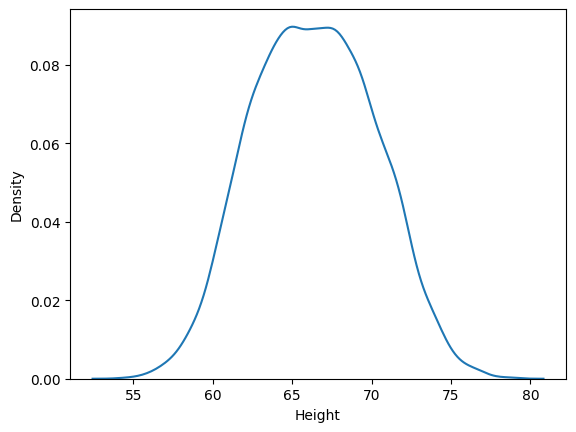

In [36]:
import seaborn as sns
sns.distplot(df['Height'],hist=False)

<Axes: ylabel='Height'>

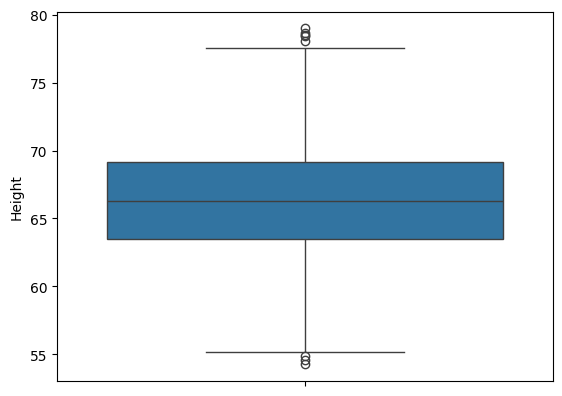

In [37]:
sns.boxplot(df['Height'])

In [38]:
upper_limit = df['Height'].quantile(0.99)
lower_limit = df['Height'].quantile(0.01)
upper_limit, lower_limit

(np.float64(74.7857900583366), np.float64(58.13441158671655))

In [39]:
new_df = df[(df['Height'] <= upper_limit) & (df['Height'] >= lower_limit)]

In [40]:
new_df['Height'].describe()

,Height
count,9800.000000
mean,66.364366
std,3.645075
min,58.134496
25%,63.577162
50%,66.318070
75%,69.119896
max,74.785714


In [41]:
df['Height'].describe()

,Height
count,10000.000000
mean,66.367560
std,3.847528
min,54.263133
25%,63.505620
50%,66.318070
75%,69.174262
max,78.998742


/tmp/ipykernel_18461/1622920233.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

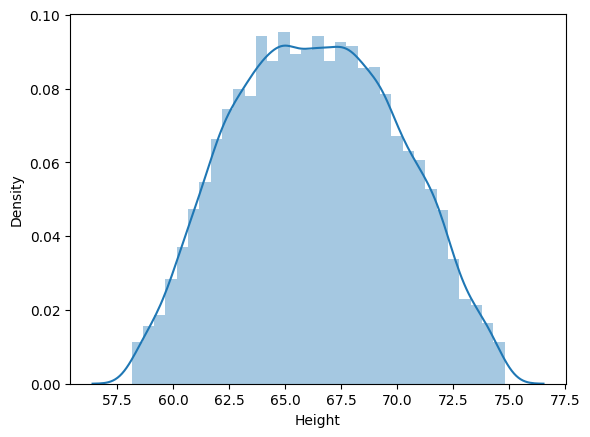

In [42]:
sns.distplot(new_df['Height'])

<Axes: ylabel='Height'>

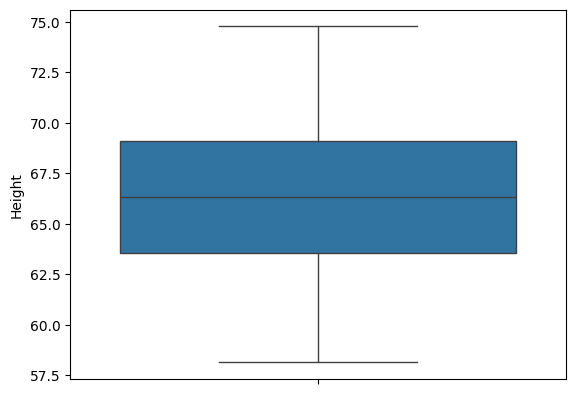

In [43]:
sns.boxplot(new_df['Height'])

In [44]:
#Capping --> Winsorization

df['Height']= np.where(
    df['Height'] >= upper_limit,
    upper_limit,
    np.where(
        df['Height'] <= lower_limit,
        lower_limit,
        df['Height']
)
)

In [45]:
df.shape

(10000, 3)

In [46]:
df['Height'].describe()

,Height
count,10000.000000
mean,66.366281
std,3.795717
min,58.134412
25%,63.505620
50%,66.318070
75%,69.174262
max,74.785790


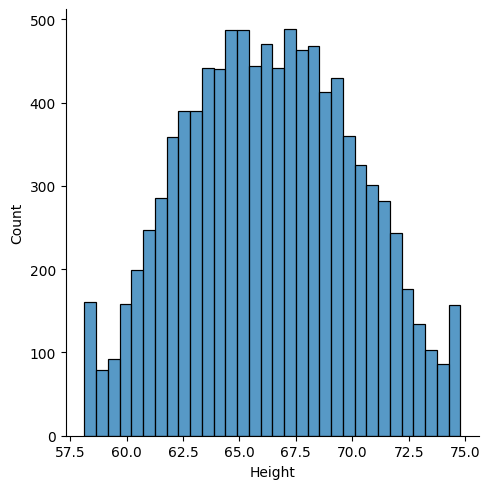

In [49]:
sns.displot(df['Height'])

<Axes: ylabel='Height'>

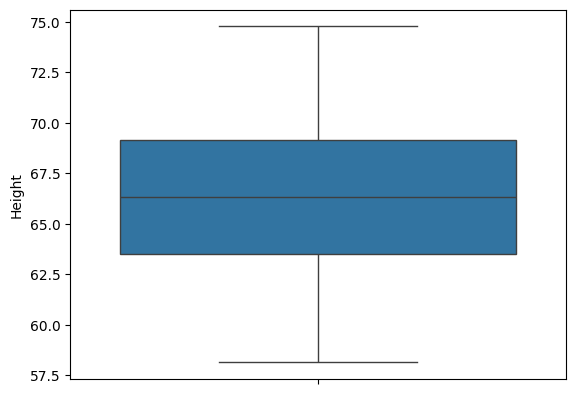

In [48]:
sns.boxplot(df['Height'])